### Anam Bhutta - Assignment 5
#### Task 1: Data Wrangling
#### Objective:
##### Clean and preprocess a given dataset by handling missing data, dealing with outliers, and transforming the data for further analysis.
#### Dataset:
##### Use the Seaborn Titanic dataset (seaborn.load_dataset("titanic")).
#### Steps to Follow:


#### 1. Data Loading: <br>
   Load the Titanic dataset using seaborn.load_dataset("titanic").

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
df = sns.load_dataset("titanic")
df


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


#### 2. Missing Data Handling:
Identify and report the missing values in the dataset. <br>
Fill the missing values: <br>
For numerical columns (age, fare), impute using the median. <br>
For categorical columns (embarked, deck), impute using the mode. <br>


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
# imputation through median
df['age'] = pd.to_numeric(df['age'])
age_median = df['age'].median()
df['age'].fillna(age_median, inplace=True)

df['fare'] = pd.to_numeric(df['fare'])
fare_median = df['fare'].median()
df['fare'].fillna(fare_median, inplace=True)

df.isnull().sum()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8112\2898214204.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(age_median, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8112\2898214204.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# imputation thru mode

deck_mode = df['deck'].mode()[0]  
df['deck'].fillna(deck_mode, inplace=True)  

embark_mode = df['embarked'].mode()[0]  
df['embarked'].fillna(embark_mode, inplace=True)  

df.isnull().sum()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8112\2615362002.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['deck'].fillna(deck_mode, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8112\2615362002.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    2
alive          0
alone          0
dtype: int64

#### 3. Outlier Detection:
Identify outliers in the age and fare columns using the IQR method (Interquartile Range).
Handle the outliers by either removing them or replacing them with the median of the column.


Text(0.5, 1.0, 'Age outliers observation')

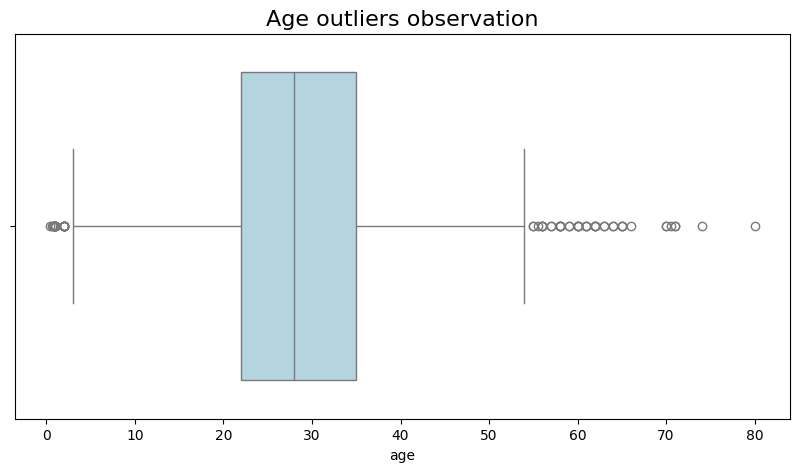

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.boxplot(x="age", data= df, color ='lightblue')
plt.title("Age outliers observation", fontsize="16")


Text(0.5, 1.0, 'Fare outliers observation')

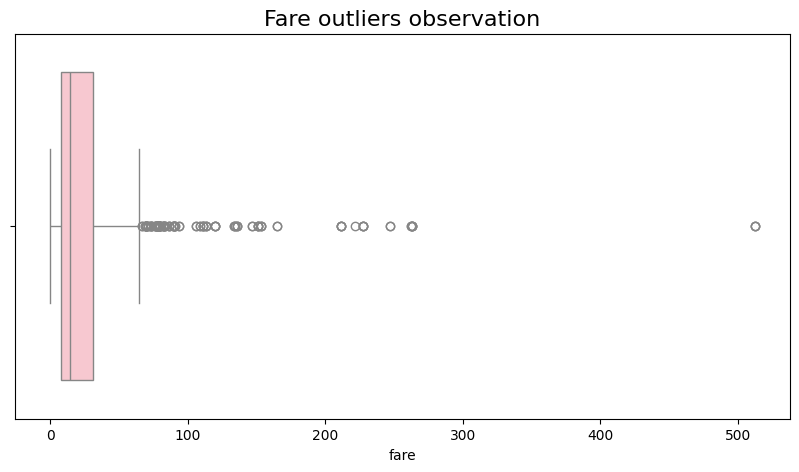

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(x="fare", data= df, color ='pink')
plt.title("Fare outliers observation", fontsize="16")


In [11]:
#confusion

age_q1 = np.percentile(df['age'], 25)
age_q3 = np.percentile(df['age'], 75)
age_iqr = age_q3 - age_q1
# upper and lower bounds 
lb = age_q1 - 1.5 * age_iqr 
ub = age_q3 + 1.5 * age_iqr 
#removing outliers
df = df[(df['age'] >= lb) & (df['age'] <= ub)]

# ship =  sns.load_dataset("titanic")

fare_q1 = np.percentile(df['age'], 25)
fare_q3 = np.percentile(df['age'], 75)
fare_iqr = fare_q3 - fare_q1
#upper and lower bounds 
fare_lb = fare_q1 - 1.5 * fare_iqr 
fare_ub = fare_q3 + 1.5 * fare_iqr 
#replacing outier with median
fare_outliers = (df['fare'] < fare_lb) | (df['fare'] > fare_ub)
median_fare = df['fare'].median()
df['fare'].loc[fare_outliers] = median_fare

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8112\4145191940.py:23: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['fare'].loc[fare_outliers] = median_fare


Text(0.5, 1.0, 'Age Outliers fixed')

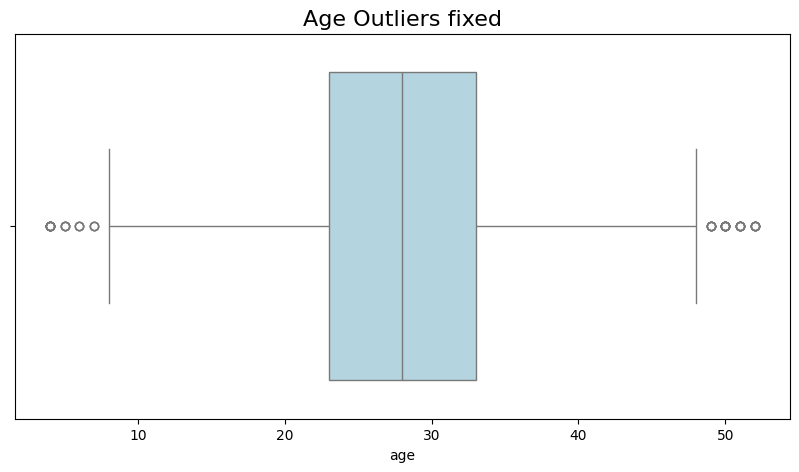

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x="age", data= df, color ='lightblue')
plt.title("Age Outliers fixed", fontsize="16")

Text(0.5, 1.0, 'Fare outliers fixed')

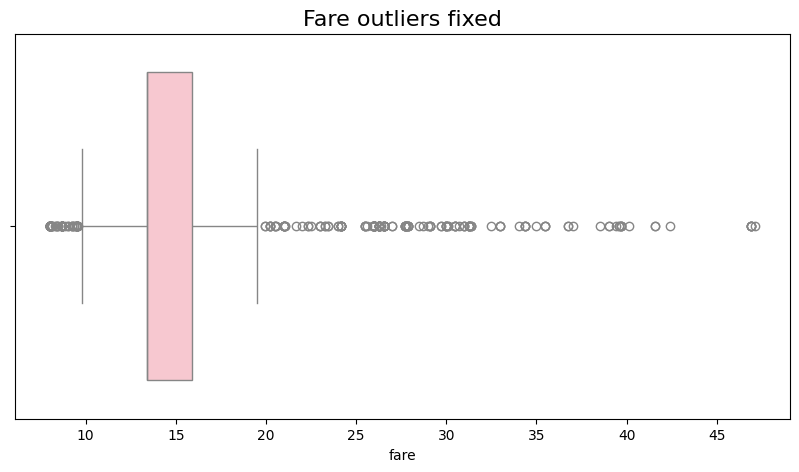

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x="fare", data= df, color ='pink')
plt.title("Fare outliers fixed", fontsize="16")


#### 4. Feature Transformation:
Create a new feature family_size: Combine the sibsp and parch columns. <br>
Create an age_group feature: Categorize passengers into "Child", "Adult", and "Senior" based on their age. <br>

In [14]:
df['family_size'] = df['sibsp'].astype(str) + df['parch'].astype(str)

bin_edges = [0, 20, 50, 100]
age_groups = ["Child", "Adult", "Senior"]

df['age_group'] = pd.cut(df['age'], bins=bin_edges, labels=age_groups)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,age_group
0,0,3,male,22.0,1,0,13.4167,S,Third,man,True,C,Southampton,no,False,10,Adult
1,1,1,female,38.0,1,0,13.4167,C,First,woman,False,C,Cherbourg,yes,False,10,Adult
2,1,3,female,26.0,0,0,13.4167,S,Third,woman,False,C,Southampton,yes,True,00,Adult
3,1,1,female,35.0,1,0,13.4167,S,First,woman,False,C,Southampton,yes,False,10,Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True,00,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,C,Southampton,no,True,00,Adult
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,00,Child
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,C,Southampton,no,False,12,Adult
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,00,Adult


#### 5. Categorical Data Encoding: 
Convert the sex column into a numerical format using Label Encoding (1 for male, 0 for female).  <br>

In [15]:
# Replace multiple values in column 'B'
df['sex'] = df['sex'].replace({'male': 1, 'female': '0'})
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,age_group
0,0,3,1,22.0,1,0,13.4167,S,Third,man,True,C,Southampton,no,False,10,Adult
1,1,1,0,38.0,1,0,13.4167,C,First,woman,False,C,Cherbourg,yes,False,10,Adult
2,1,3,0,26.0,0,0,13.4167,S,Third,woman,False,C,Southampton,yes,True,00,Adult
3,1,1,0,35.0,1,0,13.4167,S,First,woman,False,C,Southampton,yes,False,10,Adult
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True,00,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S,Second,man,True,C,Southampton,no,True,00,Adult
887,1,1,0,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,00,Child
888,0,3,0,28.0,1,2,23.4500,S,Third,woman,False,C,Southampton,no,False,12,Adult
889,1,1,1,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,00,Adult


#### 6. Normalization: 
Normalize the age and fare columns using MinMax scaling.  <br>

In [16]:
df['fare'] = (df['fare']-df['fare'].min())/(df['age'].max()-df['age'].min()) 
df['fare']

0      0.112240
1      0.112240
2      0.112240
3      0.112240
4      0.000433
         ...   
886    0.103558
887    0.457725
888    0.321267
889    0.457725
890    0.112240
Name: fare, Length: 810, dtype: float64

#### Task 2: Exploratory Data Analysis (EDA)
##### Objective:
Perform an exploratory analysis on the Titanic dataset to derive insights and visualize patterns. <br>
Dataset: <br> 
 Use the Seaborn Titanic dataset. <br>
 Steps to Follow:  <br>
 1. Univariate Analysis: <br>
    Plot histograms for numerical features (age, fare, family_size). <br>
    Visualize the distribution of the survived column using a countplot.  <br>

<Axes: xlabel='age', ylabel='Count'>

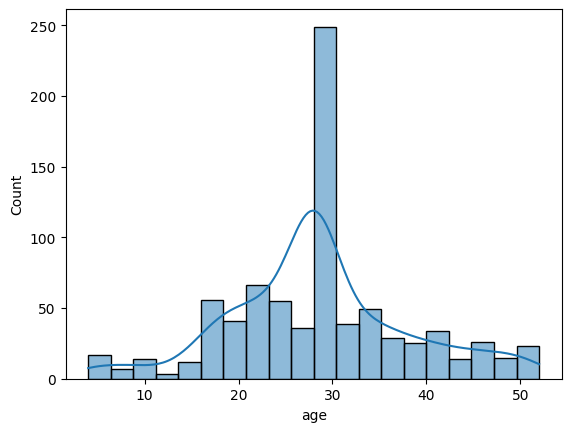

In [17]:
sns.histplot(df['age'], kde=True, bins=20)

<Axes: xlabel='fare', ylabel='Count'>

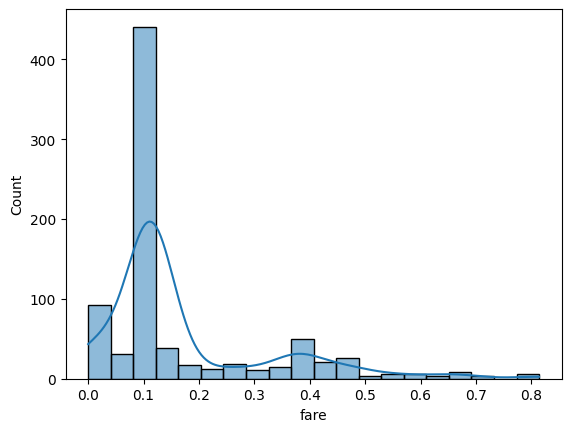

In [18]:
sns.histplot(df['fare'], kde=True, bins=20)

<Axes: xlabel='family_size', ylabel='Count'>

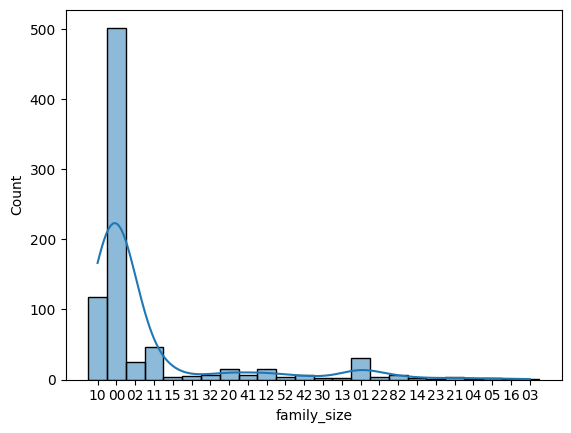

In [19]:
sns.histplot(df['family_size'], kde=True, bins=20)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8112\892896650.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='survived', data = df, palette="Purples")


<Axes: xlabel='survived', ylabel='count'>

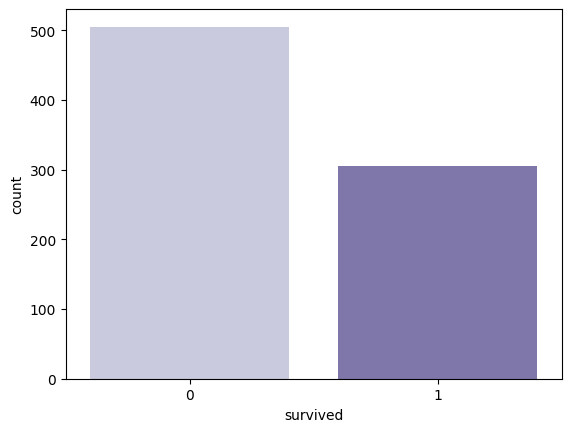

In [20]:
sns.countplot(x ='survived', data = df, palette="Purples")

 2. Bivariate Analysis: <br>
    Create a boxplot to show the distribution of fare based on the class feature. <br>
    Create a violin plot to explore how age varies across different class values. <br>
    Plot the correlation matrix of numerical features using a heatmap. <br>


<Axes: xlabel='fare', ylabel='class'>

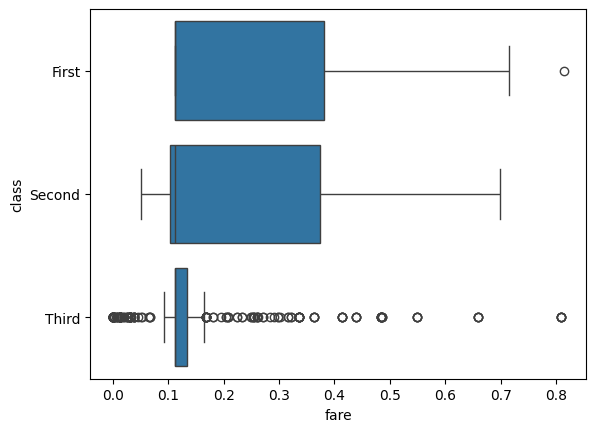

In [21]:
sns.boxplot(x= 'fare', y = 'class', data = df)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8112\1091983523.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x ="class", y ="age", data = df, palette="Pastel1")


<Axes: xlabel='class', ylabel='age'>

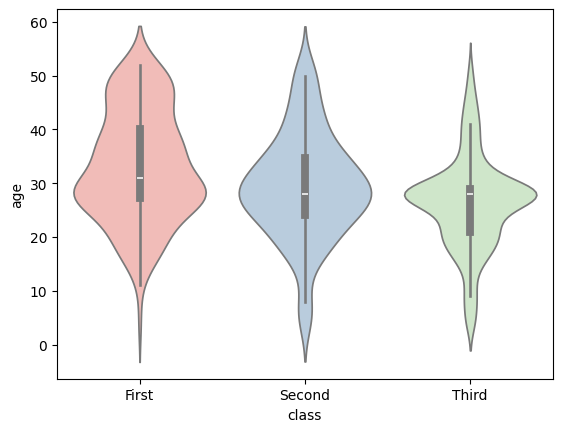

In [22]:
sns.violinplot(x ="class", y ="age", data = df, palette="Pastel1")

<Axes: >

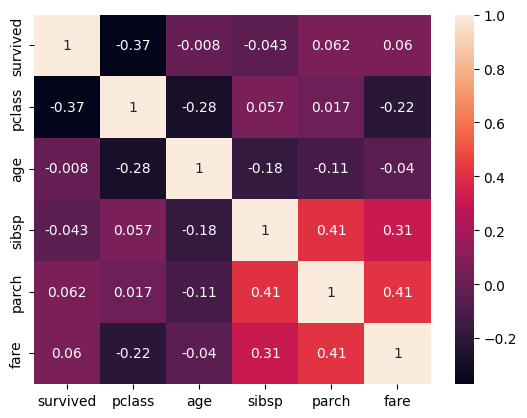

In [23]:
numeric_data = df.select_dtypes(include=['float64', 'int64'])
corr_1 = numeric_data.corr()
sns.heatmap(corr_1,annot=True)

 3. Group-wise Analysis: <br>
    Group the data by the survived column and calculate the mean of age, fare, and family_size for both survivors and non-survivors. <br>
    Create a bar plot to show the average fare for survivors vs. non-survivors. <br>

<Axes: xlabel='survived'>

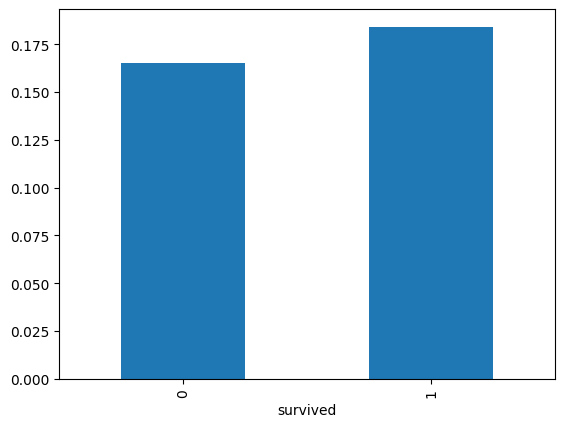

In [24]:
df['family_size'] = df['family_size'].astype(int)
grouped = df.groupby('survived')[['age', 'fare', 'family_size']].mean() 

# pd.value_counts(kashti['class']).plot.bar()
grouped['fare'].plot.bar()

 4. Multivariate Analysis: <br>
    Create a pairplot to visualize the relationships between age, fare, and family_size with survived as the hue. <br>
    Use a stacked bar plot to compare the survival rate across different class values and sex. <br>

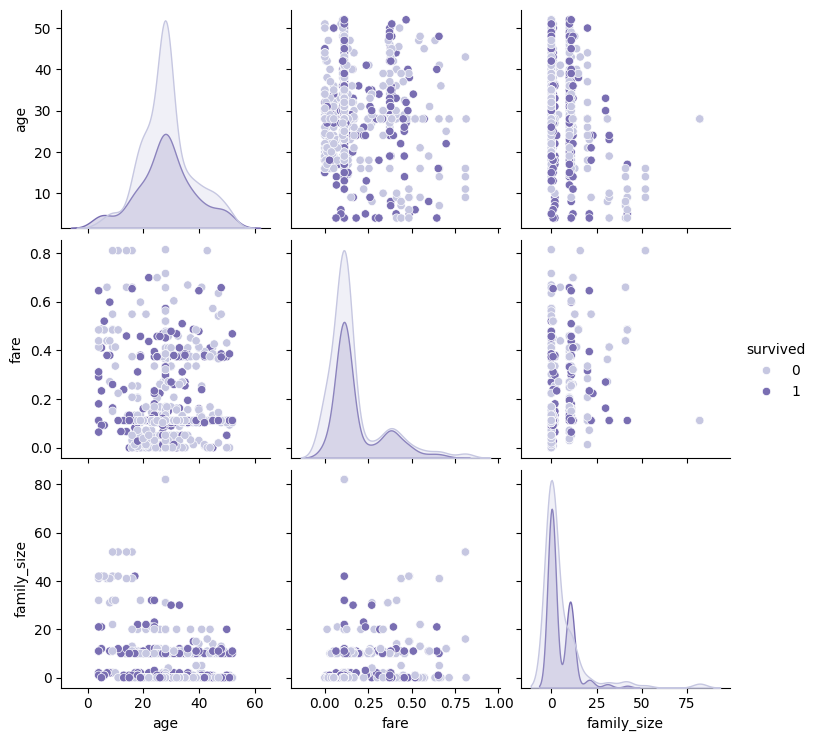

In [25]:

selected_vars = ['age', 'fare','family_size']
sns.pairplot(df, vars=selected_vars, hue = 'survived', palette='Purples')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8112\1941997207.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby(['class', 'sex'])['survived'].value_counts().unstack(fill_value=0)


<Axes: xlabel='class,sex'>

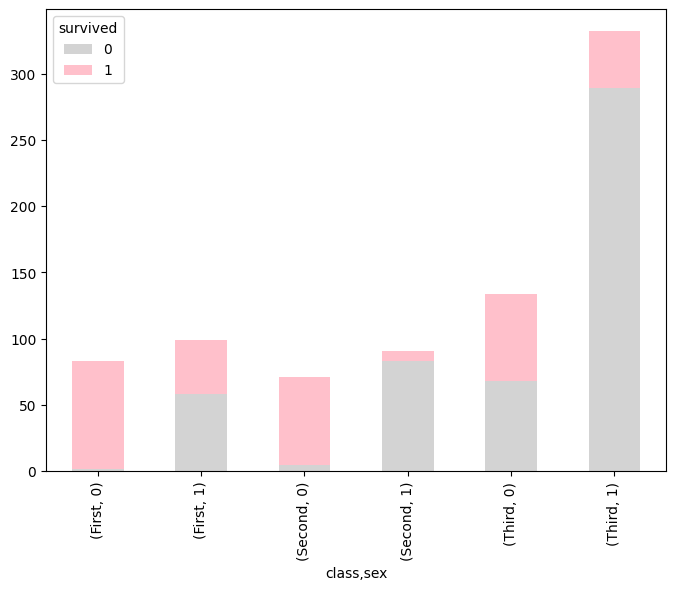

In [34]:
df['sex'] = df['sex'].astype(int)
survival_rate = df.groupby(['class', 'sex'])['survived'].value_counts().unstack(fill_value=0)
survival_rate.plot(kind='bar', stacked=True, figsize=(8, 6), color=['lightgrey', 'pink'])


# df.dtypes